### در این مثال، مدل سازی پویا برای پیش بینی قیمت نفت برنت آمریکا انجام می شود. این مدلسازی با الگوریتم LSTM  انجام می شود.
### داده های قیمت نفت برنت در بازه 17 می 1987 تا 1 نوامبر 2022 جمع آوری شده است. بخشی از داده های اصلی برای مدل سازی پویا استفاده می شود و سپس بخش دیگر برای مقایسه نتایج استفاده می شود.

مدلسازی پویا با LSTM:

یادگیری الگوهای پیچیده: می تواند الگوهای پیچیده و غیرخطی در داده ها را تشخیص دهد. الگوهای پنهان در نوسانات قیمت را پیدا می کند

حافظه دارد: مثل یک انسان که تاریخچه قیمت ها را به خاطر می سپارد و از آن یاد می گیرد

تغییرات زمانی را درک می کند: می فهمد که قیمت امروز به قیمت های دیروز، هفته گذشته و حتی ماه گذشته وابسته است. یعنی یاد می گیرد که چه زمانی قیمت ها افزایش یا کاهش پیدا می کند

## برای شروع ابتدا داده های قیمت نفت برنت از آدرس زیر دانلود و در پوشه کاری قرار داده شود.

https://github.com/hojatollahgholami/AI-in-Oil-and-gas-industry/blob/main/ex3-3/BrentOilPrices.csv


## نصب کتابخانه های موردنیاز

In [1]:
!pip install pmdarima statsmodels arabic-reshaper python-bidi torch 

## فراخوانی کتابخانه های موردنیاز

In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings, os
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings('ignore')
sns.set()

# PyTorch  جهت اجرای الگوریتم، کتابخانه های
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# کتابخانه برای نمایش فارسی در نمودارها
import arabic_reshaper
from bidi.algorithm import get_display

# تابع کمکی برای نمایش صحیح متون فارسی در نمودارها
def fa(text):
    reshaped_text = arabic_reshaper.reshape(text)
    return get_display(reshaped_text)

# تنظیمات فارسی نویسی نمودار
plt.rcParams["font.family"] = 'Adobe Arabic' 
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['font.size'] = 21

## تعریف پارامترهای ورودی

In [12]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = 'oilprice'
os.makedirs(OUTPUT_DIR, exist_ok=True)

### بارگزاری داده ها 

In [13]:
df = pd.read_csv('BrentOilPrices.csv', parse_dates=['Date'])
df = df.sort_values('Date')
df = df.groupby('Date')['Price'].mean().reset_index()
df.set_index('Date', inplace=True)

# مدیریت داده های گمشده
df.fillna(method='ffill', inplace=True) 


# به منظور کاهش نوسانات روزانه و تمرکز بر روند بلندمدت قیمت نفت از میانگین ماهانه استفاده می شود
# Resample ماهانه (میانگین)
y = df['Price'].resample('MS').mean().dropna()
y = y.to_frame()
print(y)
# نمایش داده ویرایش شده
print(f"محدوده داده: {df.index.min()} to {df.index.max()}")
df

                Price
Date                 
1987-05-01  18.580000
1987-06-01  18.860476
1987-07-01  19.856522
1987-08-01  18.979524
1987-09-01  18.313182
...               ...
2021-08-01  70.747143
2021-09-01  74.488636
2021-10-01  83.538095
2021-11-01  81.050000
2021-12-01  74.170476

[416 rows x 1 columns]
محدوده داده: 1987-05-20 00:00:00 to 2021-12-31 00:00:00


,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63
...,...
2021-12-23,76.26
2021-12-24,75.24
2021-12-29,78.63


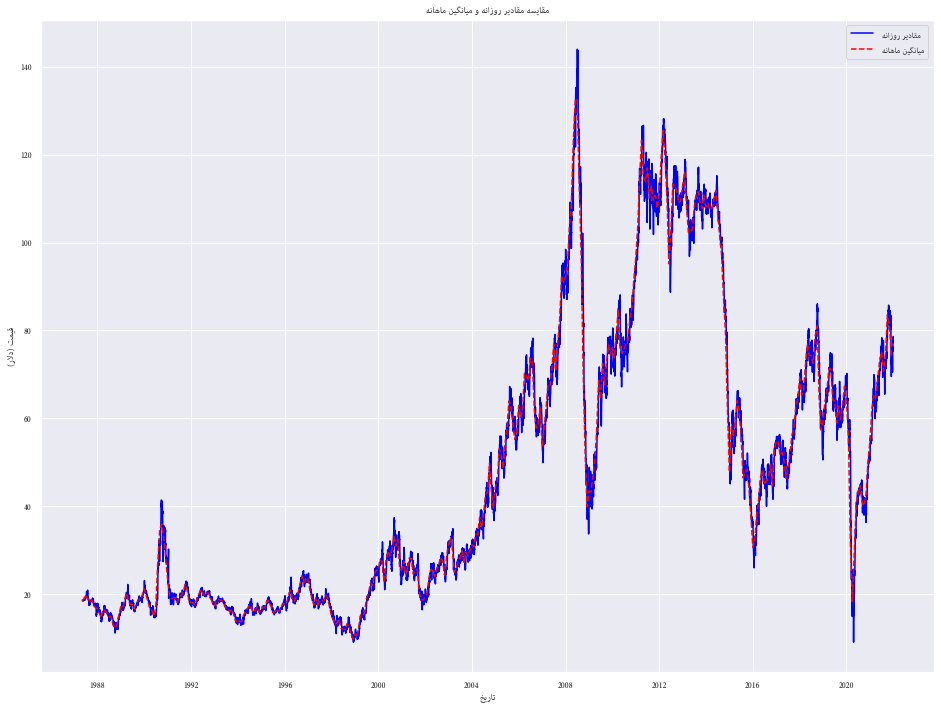

In [14]:
# نمایش نمودار مقادیر
plt.figure(figsize=(16, 12))


# Plot مقادیر روزانه و میانگین ماهانه
plt.plot(df['Price'],  label=fa('مقادیر روزانه'), color='blue')
plt.plot(y['Price'], label=fa('میانگین ماهانه'), color='red', linestyle='--')
plt.title(fa('مقایسه مقادیر روزانه و میانگین ماهانه'))
plt.ylabel(fa('قیمت (دلار)'))
plt.xlabel(fa('تاریخ'))
plt.legend()
plt.show()


### پیش پردازش

In [23]:
#  استانداردسازی 
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(y.values.reshape(-1, 1))

# جداسازی دیتاست به آموزش و تست، 70 درصد ابتدایی آموزش و 30 درصد انتهایی تست 
train_size = int(len(scaled) * 0.70)
train, test = scaled[:train_size], scaled[train_size:]

# آماده سازی داده ها جهت آموزش مدل

In [24]:
def create_dataset(arr, look_back): 
    X, Y = [], []
    n = len(arr)
    for i in range(n - look_back - 1):
        X.append(arr[i:(i+look_back), 0])
        Y.append(arr[i+look_back, 0])
    return np.array(X), np.array(Y)

look_back = 90  # بررسی چند روز گذشته look_back
X_train, Y_train = create_dataset(train, look_back)
X_test, Y_test = create_dataset(test, look_back)

# reshape برای LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

X_train_t = torch.from_numpy(X_train).float()
Y_train_t = torch.from_numpy(Y_train).float().unsqueeze(1)
X_test_t = torch.from_numpy(X_test).float()
Y_test_t = torch.from_numpy(Y_test).float().unsqueeze(1)

train_dataset = TensorDataset(X_train_t, Y_train_t)
train_loader = DataLoader(train_dataset, batch_size=15, shuffle=False)

# تعریف مدل LSTM 

In [25]:
class StackedLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=60, num_layers=3, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        out = self.fc(last)
        return out

model = StackedLSTM().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

#  آموزش مدل

In [26]:
# ---------- آموزش ----------
epochs = 50
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss/len(train_loader):.6f}")

Epoch 10/50 - Loss: 0.019096
Epoch 20/50 - Loss: 0.012691
Epoch 30/50 - Loss: 0.011353
Epoch 40/50 - Loss: 0.007974
Epoch 50/50 - Loss: 0.005999


# ارزیابی

In [27]:
model.eval()
with torch.no_grad():
    train_pred = model(X_train_t.to(device)).cpu().numpy()
    test_pred = model(X_test_t.to(device)).cpu().numpy()

train_pred_inv = scaler.inverse_transform(train_pred)
Y_train_inv = scaler.inverse_transform(Y_train.reshape(-1,1))
test_pred_inv = scaler.inverse_transform(test_pred)
Y_test_inv = scaler.inverse_transform(Y_test.reshape(-1,1))

print('LSTM Train RMSE:', np.sqrt(mean_squared_error(Y_train_inv, train_pred_inv)))
print('LSTM Test RMSE:', np.sqrt(mean_squared_error(Y_test_inv, test_pred_inv)))

# تاریخ های train/test
train_dates = y.index[look_back:train_size-1]
test_dates = y.index[train_size+look_back:-1]

LSTM Train RMSE: 8.012939981939972
LSTM Test RMSE: 15.272161228617554


# مصورسازی

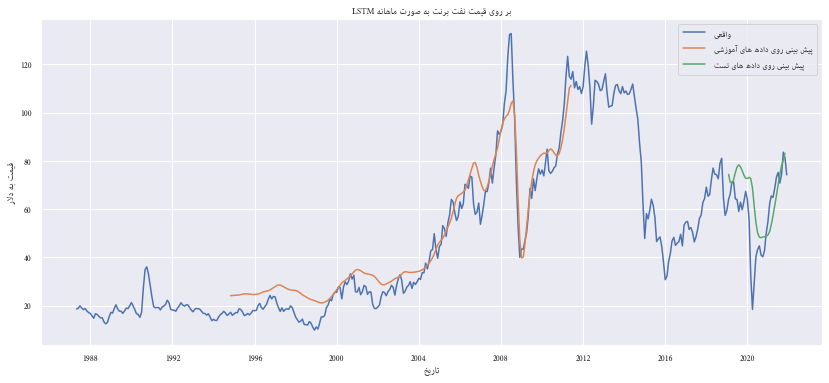

In [30]:
# ---------- نمودار مقایسه ----------
plt.figure(figsize=(14,6))
plt.plot(y.index.to_numpy(), y['Price'].to_numpy(), label=fa('واقعی'))
plt.plot(train_dates.to_numpy(), train_pred_inv, label=fa('پیش بینی روی داده های آموزشی'))
plt.plot(test_dates.to_numpy(), test_pred_inv, label=fa('پیش بینی روی داده های تست'))
plt.legend()
plt.title(fa('LSTM بر روی قیمت نفت برنت به صورت ماهانه'))
plt.xlabel(fa('تاریخ'))
plt.ylabel(fa('قیمت به دلار'))
plt.show()